# Aplicando o algortimo CMA em diversas funções

O objetivo desse notebook é implementar o algortimo em mais 6 funções a fim de comparar o desempenho e possibilitar o *benchmarking* com outros algoritmos.

**Autor:** Edélio Gabriel Magalhães de Jesus.

## Módulo para implementação do algoritmo

Neste *notebook* usaremos o módulo `pycma` [[1]](#ref-pycma), desenvolvido por Nikolaus Hansen - um dos formuladores do CMA.
A escolha foi baseada no maior alinhamento com o algoritmo original, existindo suporte para restrições não lineares, ruídos e variações discretas.

In [23]:
import numpy as np
import cma

### **Função para aplicar o algoritmo**

In [24]:
def run_cma(function, x_min, x_max, dim, max_evals, sigma, seed=367):
    evals = 0
    historico = []

    rng = np.random.default_rng(seed)

    def f(x):
        nonlocal evals
        evals += 1
        return function(x)
    
    x0 = rng.uniform(x_min, x_max, dim)
    popsize = 4 + int(3 * np.log(dim))

    optimizer = cma.CMAEvolutionStrategy(
        x0, sigma, 
        {'popsize': popsize, 'verb_disp': 0, 'seed': int(seed) if seed is not None else 0}
    )

    best = float('inf')

    while evals + popsize <= max_evals:
        X = optimizer.ask() # Amostra os pontos
        fvals = [f(x) for x in X]

        optimizer.tell(X, fvals) # Conta como foi o desempenho

        best = min(best, min(fvals)) # Salva o melhor valor
        historico.append(best)

    return best, evals, historico

`NOTAS`

`popsize`: Dado a necessídade de reprodutibilidade, definiu-se o tamanho da população de pontos amostrados como 

````python
    popsize = 4 + int(3 * np.log(dim)),
````

tendo como base a referência [[2]](#ref-cma-tutorial).

## Função para *plotar* gráfico

In [25]:
from plot_painel_functions import aplicar_estilo_artigo, plot_painel

In [26]:
'''
def _estimar_convergencia(hist, x, popsize, epsilon=1e-6):
    """
    Para cada execução, encontra a avaliação onde a melhora relativa
    ficou permanentemente abaixo de epsilon.
    Execuções que nunca convergiram recebem o valor máximo (orçamento total).
    """
    conv_evals = []
    for run in hist:
        conv_gen = None
        for i in range(1, len(run)):
            anterior = run[i - 1]
            atual = run[i]
            if anterior == 0:
                continue
            melhora_relativa = abs(anterior - atual) / abs(anterior)
            if melhora_relativa < epsilon:
                restante = run[i:]
                ref = run[i]
                if ref == 0:
                    continue
                todas_estaveis = all(
                    abs(ref - v) / abs(ref) < epsilon for v in restante
                )
                if todas_estaveis:
                    conv_gen = i
                    break
        if conv_gen is not None:
            conv_evals.append(conv_gen * popsize)
        else:
            conv_evals.append(x[-1])
    return np.array(conv_evals)


def plot_painel(hist, func, dim):
    # -------------------------------
    # Preparação dos dados
    # -------------------------------
    hist = np.asarray(hist, dtype=float)

    popsize = 4 + int(3 * np.log(dim))

    # CORRIGIDO: eixo x começa em popsize, não em 0
    x = np.arange(1, hist.shape[1] + 1) * popsize

    # estatísticas da curva
    mean_   = np.mean(hist, axis=0)
    std_    = np.std(hist, axis=0)
    median_ = np.median(hist, axis=0)
    q1_     = np.percentile(hist, 25, axis=0)
    q3_     = np.percentile(hist, 75, axis=0)

    # melhores valores finais por execução
    best_final = hist[:, -1]

    # melhor execução completa
    best_idx = np.argmin(best_final)
    best_run = hist[best_idx]

    # estimativa de convergência
    conv_evals = _estimar_convergencia(hist, x, popsize)
    n_convergiu = np.sum(conv_evals < x[-1])

    COLOR = "#3266ad"

    # -------------------------------
    # Figura — 3 linhas
    # -------------------------------
    fig = plt.figure(figsize=(14, 13))
    fig.suptitle(
        f"Análise de otimização — Função {func} {dim}D",
        fontsize=18, fontweight="bold", y=0.98
    )

    gs = gridspec.GridSpec(
        3, 2,
        figure=fig,
        hspace=0.45, wspace=0.35,
        height_ratios=[2.5, 2.5, 1]
    )

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])
    ax5 = fig.add_subplot(gs[2, :])

    # ----------------------------------------
    # 1. Mediana + IQR + melhor execução
    # ----------------------------------------
    ax1.plot(x, median_, color=COLOR, linewidth=2, label="Mediana")
    ax1.fill_between(x, q1_, q3_, color=COLOR, alpha=0.2, label="IQR")
    ax1.plot(x, best_run, color="black", linewidth=1.5,
             linestyle="--", label="Melhor execução")

    ax1.set_yscale("log")
    ax1.set_title("Convergência — mediana + IQR", fontsize=13)
    ax1.set_xlabel("Número de avaliações")
    ax1.set_ylabel("Melhor valor (log)")
    ax1.legend(fontsize=9)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)

    # ----------------------------------------
    # 2. Média ± desvio padrão (sem melhor execução)
    # ----------------------------------------
    ax2.plot(x, mean_, color=COLOR, linewidth=2, label="Média")
    ax2.fill_between(x, mean_ - std_, mean_ + std_,
                     color=COLOR, alpha=0.2, label="Desvio padrão")

    ax2.set_yscale("log")
    ax2.set_title("Convergência — média ± desvio padrão", fontsize=13)
    ax2.set_xlabel("Número de avaliações")
    ax2.set_ylabel("Melhor valor (log)")
    ax2.legend(fontsize=9)
    ax2.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)

    # ----------------------------------------
    # 3. Boxplot
    # ----------------------------------------
    bp = ax3.boxplot(
        [best_final],
        labels=[func],
        patch_artist=True,
        medianprops=dict(linewidth=1.5),
        flierprops=dict(marker="o", markersize=3, alpha=0.4),
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(COLOR)
        patch.set_alpha(0.3)

    ax3.set_yscale("log")
    ax3.set_title("Distribuição do melhor valor final", fontsize=13)
    ax3.set_ylabel("Melhor valor (log)")
    ax3.grid(True, axis="y", linestyle="--", linewidth=0.4, alpha=0.5)

    # ----------------------------------------
    # 4. ECDF
    # ----------------------------------------
    def ecdf(data):
        xs = np.sort(data)
        ys = np.arange(1, len(xs) + 1) / len(xs)
        return xs, ys

    xs, ys = ecdf(best_final)
    ax4.step(xs, ys, color=COLOR, linewidth=2, where="post")

    ax4.set_xscale("log")
    ax4.set_title("ECDF do melhor valor final", fontsize=13)
    ax4.set_xlabel("Melhor valor (log)")
    ax4.set_ylabel("Proporção acumulada")
    ax4.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)

    # ----------------------------------------
    # 5. Caixa de estatísticas
    # ----------------------------------------
    ax5.axis("off")

    n_runs = len(best_final)

    if n_convergiu > 0:
        conv_median = np.median(conv_evals[conv_evals < x[-1]])
        conv_str = f"{conv_median:.0f} aval. (mediana entre as que convergiram)"
    else:
        conv_str = "nenhuma execução convergiu dentro do orçamento"

    linhas = [
        ("Execuções",     f"{n_runs}"),
        ("Orçamento",     f"{x[-1]:.0f} avaliações por execução"),
        ("Melhor valor",  f"{np.min(best_final):.4e}"),
        ("Mediana final", f"{np.median(best_final):.4e}"),
        ("Média final",   f"{np.mean(best_final):.4e}"),
        ("Desvio padrão", f"{np.std(best_final):.4e}"),
        ("Pior valor",    f"{np.max(best_final):.4e}"),
        ("Convergência",  f"{n_convergiu}/{n_runs} execuções  —  {conv_str}"),
    ]

    ax5.text(0.5, 0.97, "Resumo estatístico", transform=ax5.transAxes,
             fontsize=12, fontweight="bold", ha="center", va="top")

    col_w = 0.5
    for i, (label, valor) in enumerate(linhas):
        col = i % 2
        row = i // 2
        x_pos = col * col_w + 0.01
        y_pos = 0.75 - row * 0.22

        ax5.text(x_pos, y_pos, f"{label}:", transform=ax5.transAxes,
                 fontsize=10, fontweight="bold", va="top", color="#444444")
        ax5.text(x_pos + 0.13, y_pos, valor, transform=ax5.transAxes,
                 fontsize=10, va="top", color="#222222")

    rect = plt.Rectangle((0, 0), 1, 1, fill=False,
                          edgecolor="#cccccc", linewidth=1,
                          transform=ax5.transAxes, clip_on=False)
    ax5.add_patch(rect)

    plt.show()
'''

'\ndef _estimar_convergencia(hist, x, popsize, epsilon=1e-6):\n    """\n    Para cada execução, encontra a avaliação onde a melhora relativa\n    ficou permanentemente abaixo de epsilon.\n    Execuções que nunca convergiram recebem o valor máximo (orçamento total).\n    """\n    conv_evals = []\n    for run in hist:\n        conv_gen = None\n        for i in range(1, len(run)):\n            anterior = run[i - 1]\n            atual = run[i]\n            if anterior == 0:\n                continue\n            melhora_relativa = abs(anterior - atual) / abs(anterior)\n            if melhora_relativa < epsilon:\n                restante = run[i:]\n                ref = run[i]\n                if ref == 0:\n                    continue\n                todas_estaveis = all(\n                    abs(ref - v) / abs(ref) < epsilon for v in restante\n                )\n                if todas_estaveis:\n                    conv_gen = i\n                    break\n        if conv_gen is not Non

## Funções de análise

Para esse *notebook*, foram elencadas 7 funções, separadas nas seguintes classes:

`Muitos mínimos locais`

- Levy
- Rastrigin
- Schwefel

`Forma de vale`:

- Rosenbrock

`Convexa`:

- Sphere 

A partir desses casos, podemos construir uma boa fundamentação para comparar o CMA com outros algoritmos de otimização *derivate-free*.

---

Vamos definir alguns parâmetros gerais

In [27]:
SEED = 367
sigma = 0.5
dim = 20
max_evals = 5000
n_iter = 50

`NOTA`:

Os intervalos de amostragem serão definidos conforme a especificidade de cada função, tendo como base a referência [[3]](#ref-library).

---

### **Função: Levy**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/levy.png" alt="Função de Levy" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = \sin^2(\pi w_1) + \sum_{i=1}^{d-1}(w_i - 1)^2[1+ 10sin^2(\pi w_i + 1)] + (w_d - 1)^2[1 + \sin^2(2\pi w_d)]
$$

onde

$$
w_i = 1 + \frac{x_i -1}{4}
$$

para $i = 1, ..., d$.

In [28]:
def levy(x):
    x = np.asarray(x, dtype=float)
    w = 1 + (x - 1) / 4
    
    term1 = np.sin(np.pi * w[0])**2
    
    term2 = np.sum(
        (w[:-1] - 1)**2 * (1 + 10 * np.sin(np.pi * w[:-1] + 1)**2)
    )
    
    term3 = (w[-1] - 1)**2 * (1 + np.sin(2 * np.pi * w[-1])**2)
    
    return term1 + term2 + term3

In [29]:
hist_levy = []

for i in range (n_iter):
    seed = SEED + i

    best, evals, hist = run_cma(function=levy, x_min=-10, x_max=10, dim=dim, max_evals=max_evals,sigma=sigma, seed=seed)

    hist_levy.append(hist)
    

In [30]:
best

np.float64(28.824906043247)

---

``Vamos plotar os resultados``

---

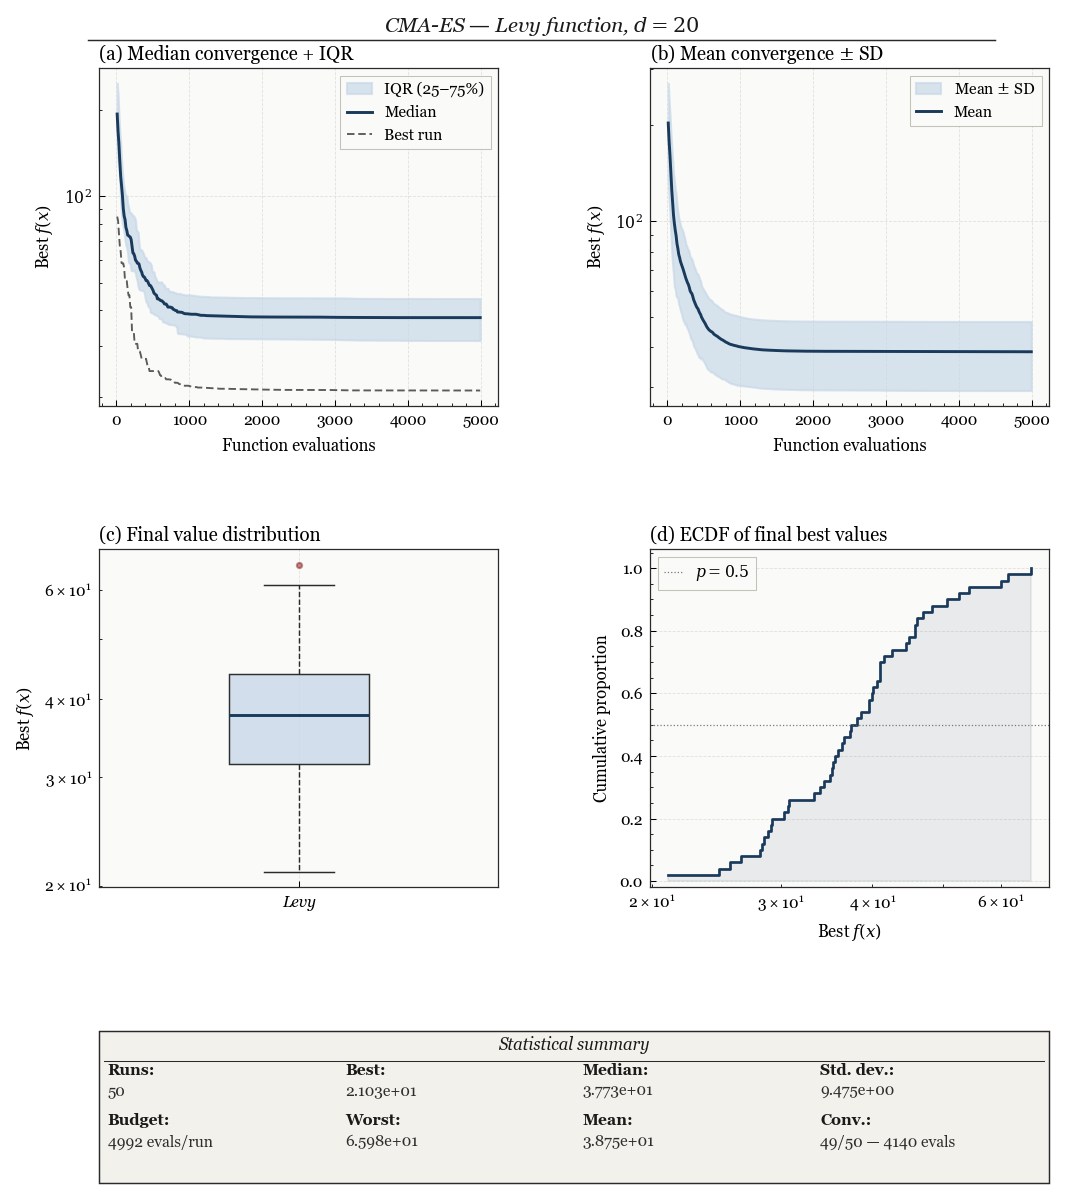

In [31]:
plot_painel(hist_levy, func='Levy', dim=dim)

### **Função Rastrigin**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/rastr.png" alt="Função de Levy" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = 10d + \sum_{i=1}^d[x_i^2 - 10cos(2\pi x_i)]
$$

In [32]:
def rastrigin(x):
    x = np.asarray(x, dtype=float)
    d = len(x)

    return (
        10 * d + np.sum(x ** 2 - 10 * np.cos(2 * np.pi * x))
    )

In [33]:
hist_rastringin = []

for i in range (n_iter):
    seed = SEED + i

    best, evals, hist = run_cma(function=rastrigin, x_min=-5.12, x_max=5.12, dim=dim, max_evals=max_evals,sigma=sigma, seed=seed)

    hist_rastringin.append(hist)
    

In [34]:
best

np.float64(87.55605354146066)

---

Vamos visualizar os resultados

---

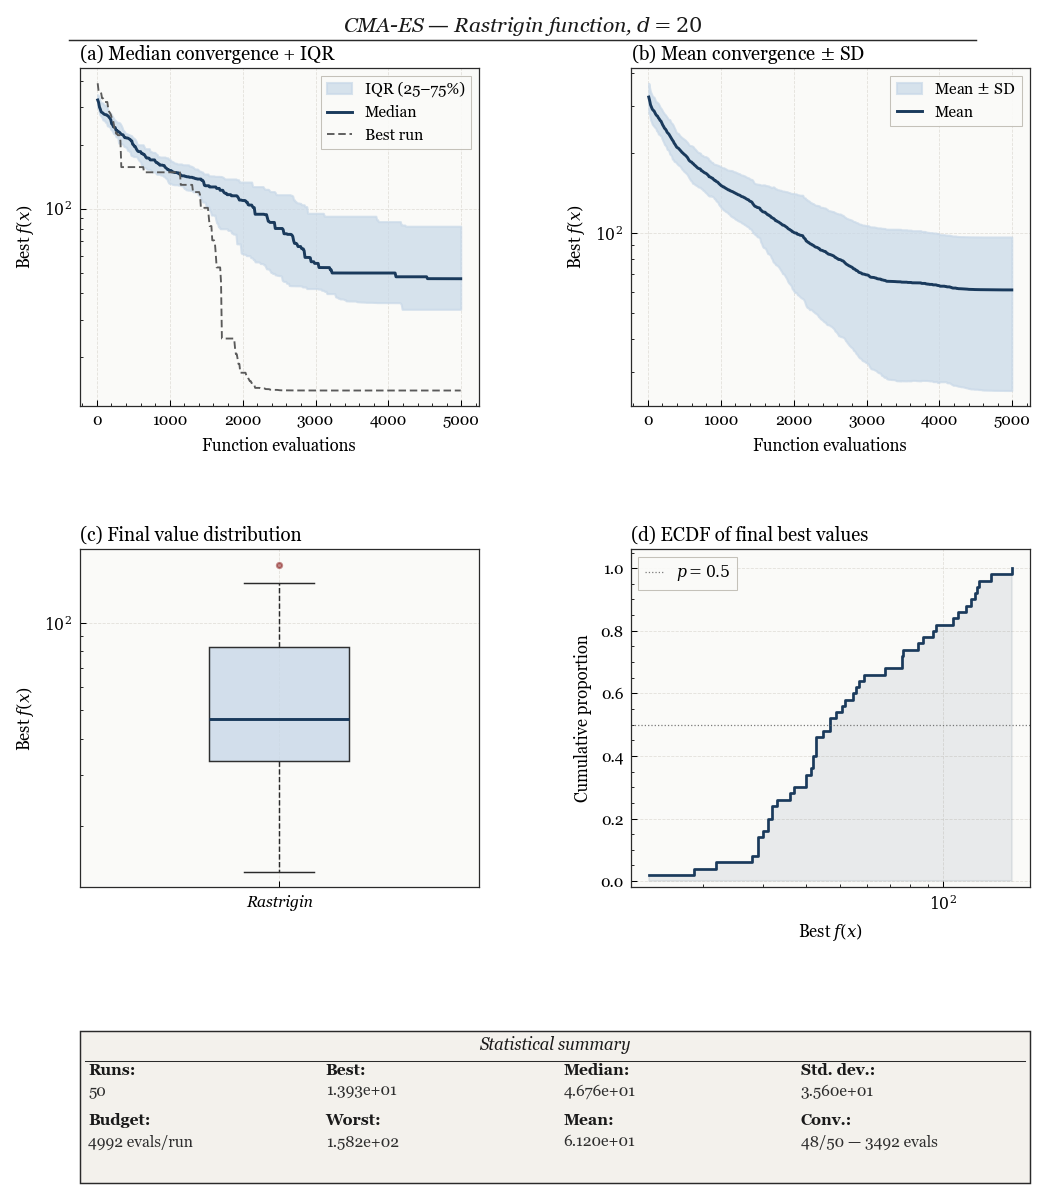

In [35]:
plot_painel(hist_rastringin, func='Rastrigin', dim=dim)

### **Função Schwefel**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/schwef.png" alt="Função de Levy" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = 418.9829d - \sum_{i=1}^dx_i\sin(\sqrt(|x_i|))
$$

In [36]:
def schwefel(x):
    x = np.asarray(x, dtype=float)
    d = x.size
    
    return 418.9829 * d - np.sum(x * np.sin(np.sqrt(np.abs(x))))

In [37]:
hist_schwefel = []

for i in range (n_iter):
    seed = SEED + i

    best, evals, hist = run_cma(function=schwefel, x_min=-500, x_max=500, dim=dim, max_evals=max_evals,sigma=sigma, seed=seed)

    hist_schwefel.append(hist)

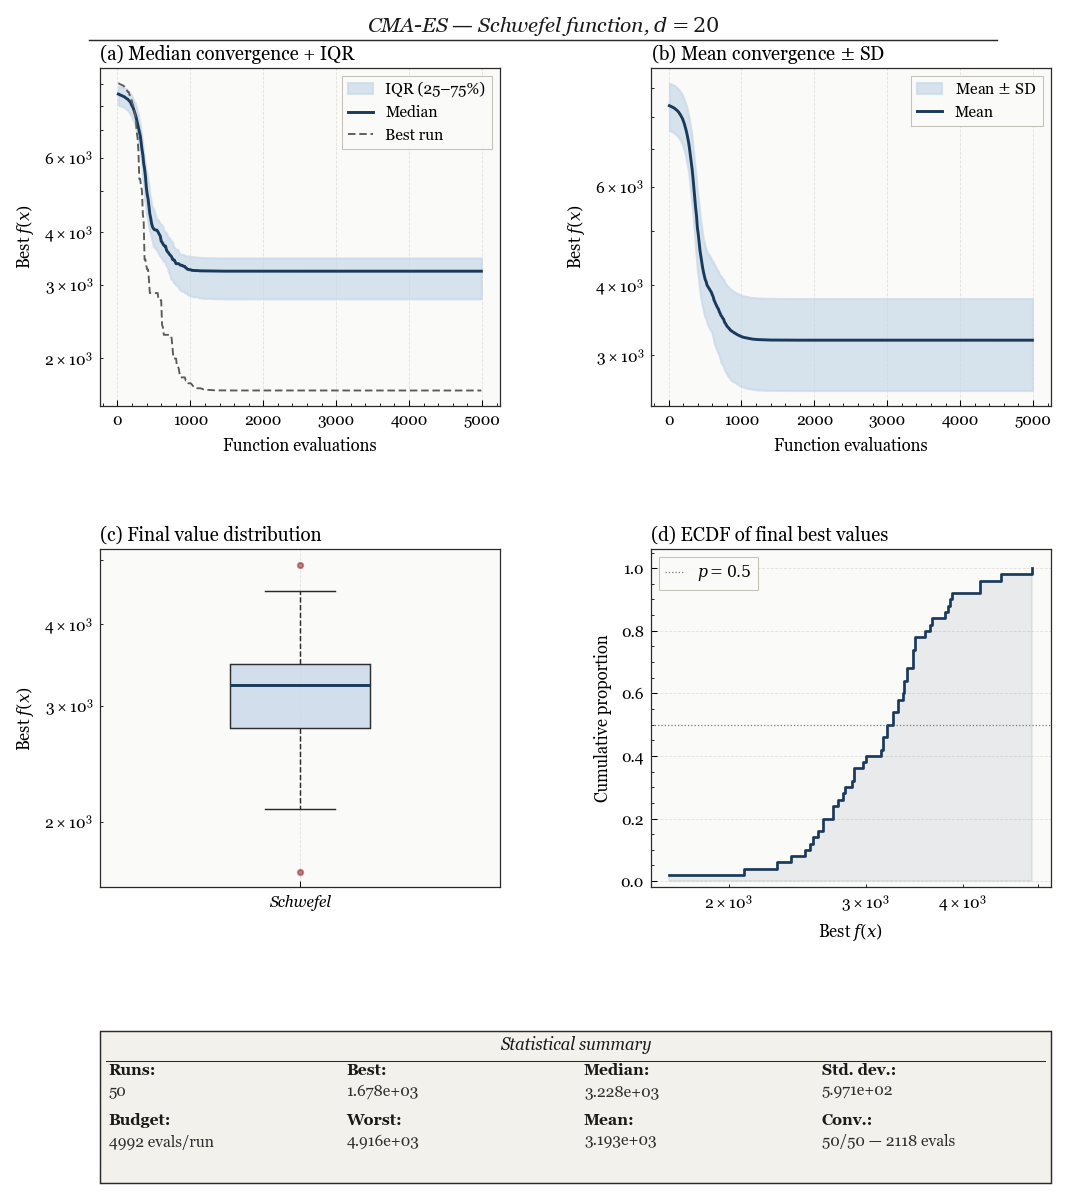

In [38]:
plot_painel(hist_schwefel, func='Schwefel', dim=dim)

### **Função Rosenbrock**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/rosen.png" alt="Função de Levy" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = \sum_{i=1}^{d-1}[100(x_{i+1} - x_i^2)^2 + (x_i -1)^2]

In [39]:
def rosenbrock(x):
    x = np.array(x)

    return np.sum(
        100 * (x[1:] - x[:-1]**2)**2 + (x[:-1] - 1)**2
    )

---

Adivinha? Vamos olhar os resultados!

---

In [40]:
hist_rosenbrock = []

for i in range (n_iter):
    seed = SEED + i

    best, evals, hist = run_cma(function=rosenbrock, x_min=-2.048, x_max=2.048, dim=dim, max_evals=max_evals,sigma=sigma, seed=seed)

    hist_rosenbrock.append(hist)
    

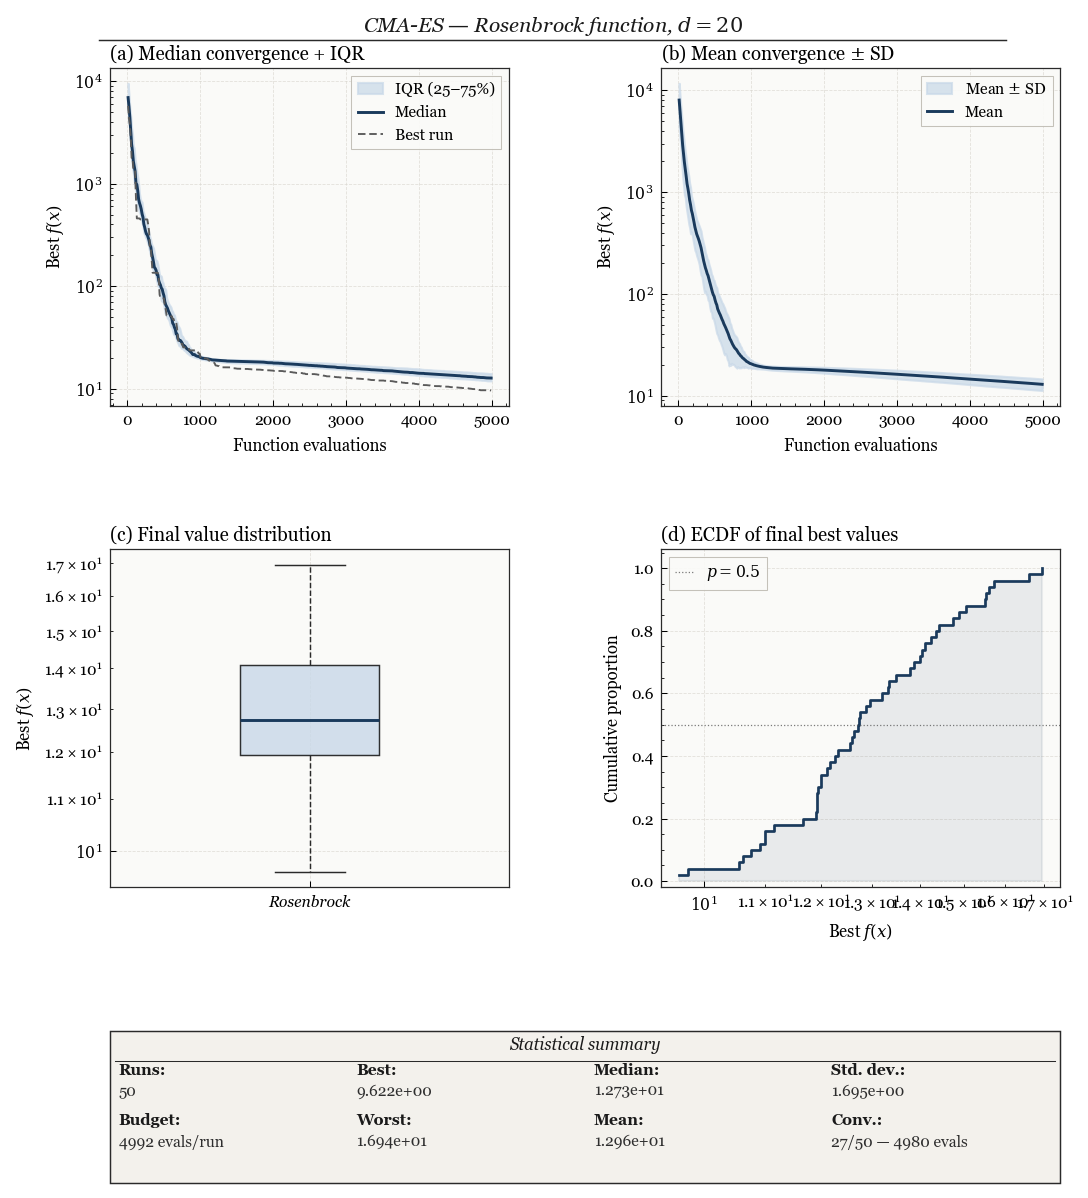

In [41]:
plot_painel(hist_rosenbrock, func='Rosenbrock', dim=dim)

### **Função Sphere**

<div style="text-align: center;">
  <img src="https://www.sfu.ca/~ssurjano/spheref.png" alt="Função de Levy" width="500">
</div>

[Fonte: Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/index.html)

$$
f(x) = \sum_{i=1}^dx_i^2
$$

In [42]:
def sphere(x):
    x = np.asarray(x, dtype=float)

    return (
        np.sum(x**2)
    )

In [43]:
hist_sphere = []

for i in range (n_iter):
    seed = SEED + i

    best, evals, hist = run_cma(function=sphere, x_min=-5.12, x_max=5.12, dim=dim, max_evals=max_evals,sigma=sigma, seed=seed)

    hist_sphere.append(hist)    

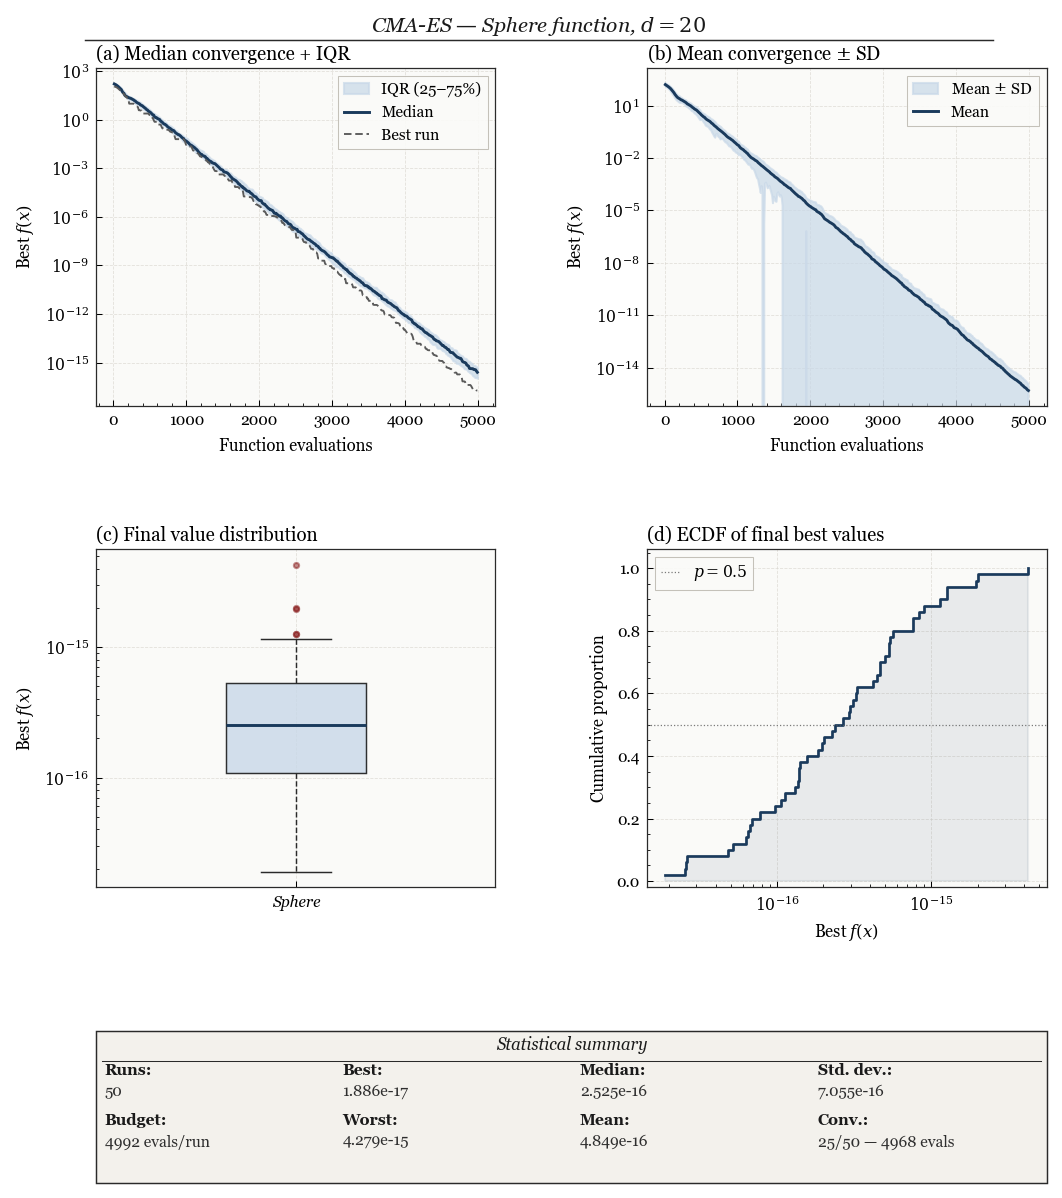

In [44]:
plot_painel(hist_sphere, func='Sphere',dim=dim)

## Referências

<a id="ref-pycma"></a> [1] [CMA-ES/pycma on Github](https://doi.org/10.5281/zenodo.2559634)

<a id="ref-cma-tutorial"></a> [2] [HANSEN, Nikolaus. The CMA evolution strategy: A tutorial. arXiv preprint arXiv:1604.00772, 2016.](https://doi.org/10.48550/arXiv.1604.00772)

<a id="ref-library"></a> [3] [Virtual Library of Simulation Experiments](https://www.sfu.ca/~ssurjano/levy.html)